In [1]:
!pip3 install pandas
!pip3 install numpy

In [2]:
import os
import pandas as pd
import numpy as np
import glob
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# Setting parameters
M = 20
CLIENT_IP = "172.29.250.200"
captures_folder = "/content/drive/MyDrive/captures/raw_data/check_data"
output_file = "app_fingerprints.csv"

# Get all CSV files
csv_files = glob.glob(os.path.join(captures_folder, "*.csv"))
results = []

# Process each file
for file_path in csv_files:
    # Extract app
    base_name = os.path.basename(file_path)
    app_name = base_name.split('_')[0]

    # Reading CSV Files
    df = pd.read_csv(file_path)

    # Calculating Packet Size
    packet_sizes = df['frame.len'].tolist()

    # Determine packet direction
    directions = []
    for idx, row in df.iterrows():
        if row['ip.src'] == CLIENT_IP:
            directions.append(-1)  # uplink is -1
        else:
            directions.append(1)   # downlink is 1

    directed_sizes = [size * direction for size, direction in zip(packet_sizes, directions)]

    # Filter out TCP ACKs
    filtered_sizes = []
    for i, size in enumerate(directed_sizes):
        if df['tcp.len'].iloc[i] > 0:
            filtered_sizes.append(size)

    # Calculate C
    C = np.cumsum(filtered_sizes)

    # Sampling points
    if len(C) == 1:
        # When one point, = M
        sampled_C = np.array([C[0]] * M)
    else:
        # Multiple points
        x_orig = np.arange(1, len(C) + 1)
        f = interp1d(x_orig, C, kind='linear')
        x_new = np.linspace(1, len(C), M)
        sampled_C = f(x_new)

    # Combine app and fingerprint
    row = [app_name] + sampled_C.tolist()
    results.append(row)

# Create header
header = ["app"] + [f"feature_{i}" for i in range(M)]

# Save
with open(output_file, 'w') as f:
    # Write header
    f.write(",".join(header) + '\n')

    # Write Data
    for row in results:
        line = f"{row[0]}," + ",".join([str(val) for val in row[1:]])
        f.write(line + '\n')

print(f"Save to file: {output_file}")
print(f"A total of {len(results)} files")

Save to file: app_fingerprints.csv
A total of 60 files


k=1, Accuracy: 0.9167
k=2, Accuracy: 0.8333
k=3, Accuracy: 0.8833
k=4, Accuracy: 0.8333
k=5, Accuracy: 0.8167
k=6, Accuracy: 0.7500
k=7, Accuracy: 0.7667
k=8, Accuracy: 0.7333
k=9, Accuracy: 0.6833
k=10, Accuracy: 0.6833

The optimal k value is 1，the corresponding accuracy is 0.9167


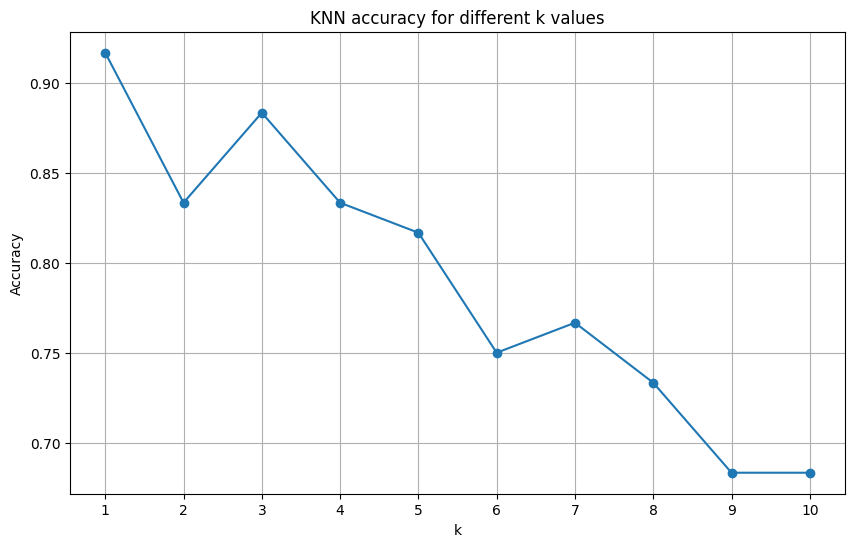

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


# Reading the dataset
dataset = pd.read_csv('/content/drive/MyDrive/captures/processed_data/train_proc/app_fingerprints_train.csv')

# Data preprocessing
X = dataset.dropna()
APP = X['app']
X = X.drop(['app'], axis=1)

# Divide the training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, APP, test_size=0.3, random_state=36)

# Feature Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Using different k values
k_values = range(1, 11)
accuracies = []

for k in k_values:
    # Create and train a KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    # Make predictions on the test set
    y_pred = knn.predict(X_test_scaled)

    # Calculation accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    print(f"k={k}, Accuracy: {accuracy:.4f}")

# Find the best k value
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)
print(f"\nThe optimal k value is {best_k}，the corresponding accuracy is {best_accuracy:.4f}")

# Visualize the accuracy for different k values
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('KNN accuracy for different k values')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.savefig('knn_accuracy.png')
plt.show()



Test Results with k=1:
Accuracy: 0.7333


<Figure size 1000x800 with 0 Axes>

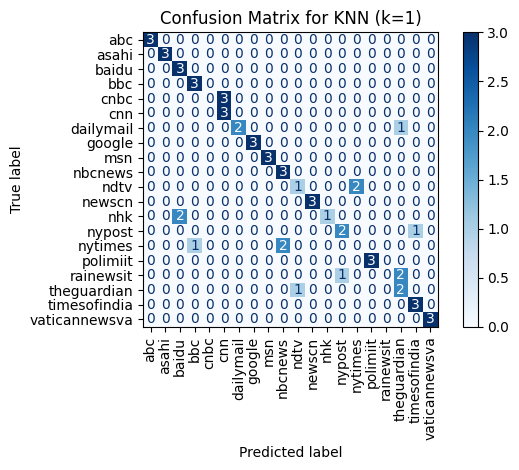

In [4]:
def test_knn_model(best_k, scaler, X_train, y_train, check_data_path):

    # Read the dataset
    check_dataset = pd.read_csv(check_data_path)

    # Process the data
    X_check = check_dataset.dropna()
    y_check = X_check['app']
    X_check = X_check.drop(['app'], axis=1)

    # Ensure X_check has the same columns as X_train
    if set(X_check.columns) != set(X_train.columns):
        raise ValueError(f"Test data columns {X_check.columns} don't match training data columns {X_train.columns}")

    # Reorder columns
    X_check = X_check[X_train.columns]
    X_check_scaled = scaler.transform(X_check)

    # Create and train a KNN classifier with the best k
    knn = KNeighborsClassifier(n_neighbors=best_k)
    knn.fit(X_train_scaled, y_train)
    # Calculate accuracy
    y_pred = knn.predict(X_check_scaled)
    accuracy = accuracy_score(y_check, y_pred)
    # Confusion matrix
    cm = confusion_matrix(y_check, y_pred)
    plt.figure(figsize=(10, 8))

    classes = sorted(y_check.unique())

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap=plt.cm.Blues, xticks_rotation=90)
    plt.title(f'Confusion Matrix for KNN (k={best_k})')
    plt.tight_layout()
    plt.savefig('knn_confusion_matrix.png')

    # Create a dataframe with actual and predicted values
    results_df = pd.DataFrame({
        'Actual': y_check,
        'Predicted': y_pred
    })

    # Count occurrences for each app category
    actual_counts = results_df['Actual'].value_counts()
    pred_counts = results_df['Predicted'].value_counts()

    all_apps = sorted(set(actual_counts.index) | set(pred_counts.index))
    actual_counts = actual_counts.reindex(all_apps, fill_value=0)
    pred_counts = pred_counts.reindex(all_apps, fill_value=0)


    return accuracy, cm, knn

# Check data
check_data_path = '/content/drive/MyDrive/captures/processed_data/check_proc/app_fingerprints_check.csv'

# Test the model
test_accuracy, conf_matrix, best_model = test_knn_model(
    best_k,
    scaler,
    X_train,
    y_train,
    check_data_path
)

# Print detailed results
print(f"\nTest Results with k={best_k}:")
print(f"Accuracy: {test_accuracy:.4f}")

plt.show()